 # Beyond the Hype: AI vs Traditional Investing
 Comparative Analysis of Portfolio Risk and Return (2020–2025)

 **Author**: Alena
 
 **Date**: August 2026 
 
 **Data Source**: Yahoo Finance (via yfinance)
 
 **Tools**: Python, Pandas, NumPy, Plotly, DuckDB, yfinance

 ---
 
 **Insight**: 
 Everyone talks about AI. But is higher return enough to justify higher risk?
 
 **Research Question**: 
 How did two different portfolios respond to major macroeconomic events and the AI boom between 2020 and 2025?
 
 **Objective**:
 To identify which portfolio delivered better risk-adjusted performance between 2020 and 2025.
 
 
 **Portfolio Construction**:
 
 **AI Portfolio**:
 
 NVIDIA (NVDA) — 33.3% — Leader in AI chips and GPU computing.
 
 Microsoft (MSFT) — 33.3% — Cloud computing and AI services.
 
 Broadcom (AVGO) — 33.3% — Semiconductors and AI infrastructure.

 **Traditional Portfolio**:
 
 SPDR S&P 500 ETF (SPY) — 33.3% — Tracks the S&P 500 Index.
 
 SPDR Gold Shares (GLD) — 33.3% — Traditional safe-haven asset.
 
 iShares 20+ Year Treasury Bond ETF (TLT) — 33.3% — Long-term U.S. government bonds.

 **Data & Methodology**:
 
 **Data**:
 
 *Analysis period*: January 2020 – December 2025
 
 *Price frequency*: Daily Adjusted Close prices
 
 *Portfolio strategy*: Buy & Hold
 
 *Portfolio weights*: Equal-weighted (33.3% each)
 
 *Rebalancing*: None
 
 *Dividends*: Dividends reinvested (via Adjusted Close)
 
 *Transaction costs, taxes and inflation are not included*.

 **Performance Metrics**:
 
 - Total Cumulative Return
 
 - CAGR
 
 **Risk Metrics**:
 
 - 90-Day Rolling Volatility
 
 - Drawdowns
 
 - Recovery Time
 

 **Market Context:**
The analysis period (2020–2025) includes five major events:

1. The **COVID-19 crash and oil market shock** (2020).
 
2. High **inflation and rising interest rates** (2022–2023).
 
3. The **US banking crisis** (2023).
 
4. New **trade tariffs and policy changes** (2025).

 These events help us see how each portfolio handles stress and recovery.  

  **Risk-Adjusted Metrics**:
 
 - Sharpe Ratio
 
 - Sortino Ratio

 **Correlation & Diversification**


 **Conclusion**


 ## 1. Data Collection & Setup

This section imports the required Python libraries, downloads historical market data from Yahoo Finance, and prepares the dataset for analysis in Python and DuckDB.
 



 
 
 
 
 


In [17]:
# Importing libraries
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import duckdb

In [18]:
# Downloading historical data via yfinance
tickers = [ 'MSFT', 'NVDA', 'AVGO', 'GLD', 'SPY', 'TLT' ]
prices = yf.download(
    tickers=tickers,
    start= '2020-01-01',
    end= '2026-01-01',
    auto_adjust= True,
    progress= False
)
prices = prices ['Close']
prices.head ()

Ticker,AVGO,GLD,MSFT,NVDA,SPY,TLT
Date,,,,,,
2020-01-02,27.633759,143.949997,151.544250,5.963805,296.125244,112.001869
2020-01-03,26.930899,145.860001,149.657272,5.868346,293.882904,113.726685
2020-01-06,26.890606,147.389999,150.044113,5.892957,295.004120,113.080864
2020-01-07,26.798033,147.970001,148.676041,5.964302,294.174652,112.524994
2020-01-08,26.463737,146.860001,151.044220,5.975487,295.742493,111.781082


In [19]:
## 2. Data Quality Check
prices.info()
prices.isna().sum()

<class 'pandas.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AVGO    1508 non-null   float64
 1   GLD     1508 non-null   float64
 2   MSFT    1508 non-null   float64
 3   NVDA    1508 non-null   float64
 4   SPY     1508 non-null   float64
 5   TLT     1508 non-null   float64
dtypes: float64(6)
memory usage: 82.5 KB


Ticker
AVGO    0
GLD     0
MSFT    0
NVDA    0
SPY     0
TLT     0
dtype: int64

## 2. Portfolio Returns. Performance Analysis

In [20]:
# Calculating the return for each asset
returns = prices.pct_change()
# Deleting the first row so there's nothing to compare it to 
returns = returns.dropna()
# Test
print( returns.head())

Ticker          AVGO       GLD      MSFT      NVDA       SPY       TLT
Date                                                                  
2020-01-03 -0.025435  0.013269 -0.012452 -0.016006 -0.007572  0.015400
2020-01-06 -0.001496  0.010490  0.002585  0.004194  0.003815 -0.005679
2020-01-07 -0.003443  0.003935 -0.009118  0.012107 -0.002812 -0.004916
2020-01-08 -0.012475 -0.007502  0.015928  0.001875  0.005330 -0.006611
2020-01-09 -0.008032 -0.005652  0.012493  0.010983  0.006781  0.003511


In [21]:
# Split them into two separate portfolios
ai = [ 'NVDA', 'MSFT', 'AVGO']
classic = [ 'GLD', 'SPY', 'TLT' ]
# Weights (33.3% = 1/3 for each asset in the portfolio)
weights = np.array([1/3, 1/3, 1/3])

In [22]:
# Calculating portfolio daily return
return_ai = (returns[ai] * weights ).sum(axis=1)
return_classic = (returns [classic] *  weights ).sum(axis=1)
# Adding calculations to our dataframe
returns['AI_Portfolio'] = return_ai
returns['Classic_Portfolio'] = return_classic

In [23]:
# A simulation of investing $10,000 in both portfolios 
# What would we get if we invested this amount for 5 years and reinvested the dividends?
growth_ai = 10000 * (1 + return_ai).cumprod()
growth_classic = 10000 * (1 + return_classic).cumprod()
growth = pd.DataFrame({
    "AI Portfolio": growth_ai,
    "Classic Portfolio": growth_classic
})

growth.head()

,AI Portfolio,Classic Portfolio
Date,,
2020-01-03,9820.357061,10070.320442
2020-01-06,9837.649229,10099.275880
2020-01-07,9836.161825,10086.509548
2020-01-08,9853.634737,10056.979678
2020-01-09,9904.359114,10072.534175


In [24]:
# Total cumulative return
total_return_ai = (growth_ai.iloc[-1] / 10000 - 1) * 100
total_return_classic = (growth_classic.iloc[-1] / 10000 - 1) * 100

print("AI total return:", total_return_ai)
print("Classic total return:", total_return_classic)

AI total return: 1142.6094338647156
Classic total return: 78.93679777270408


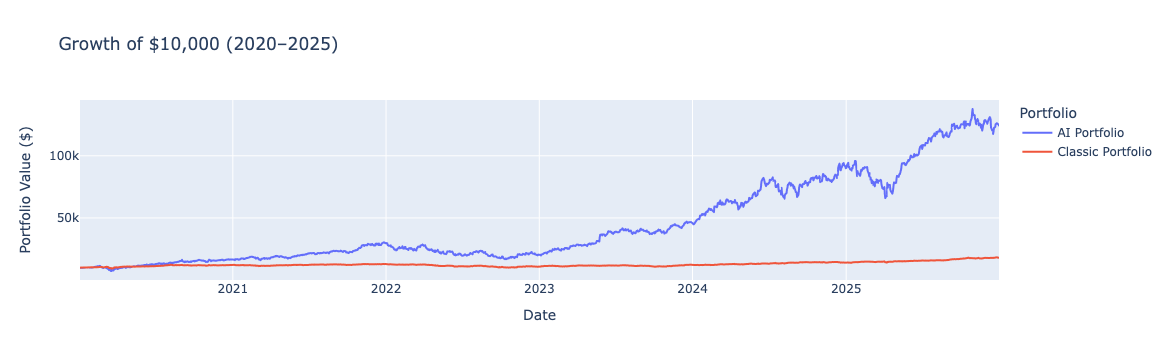

In [25]:
# Building a growth chart via plotly.express 

fig = px.line(
    growth,
    x=growth.index,
    y=["AI Portfolio", "Classic Portfolio"],
    title="Growth of $10,000 (2020–2025)",
    labels={
        "value": "Portfolio Value ($)",
        "Date": "Date",
        "variable": "Portfolio"
    }
)

fig.show()

**The cumulative total return over 5 years was**: 
- **AI**: 1,142.61% (124,260.02$)

- **Classic**: 78.94% (17,893.68$)

In [26]:
# Created a new table for SQL from Python memory
returns_for_sql = returns.reset_index()

In [27]:
# Calculating annual returns via DuckDB
con = duckdb.connect()
con.register("returns_for_sql", returns_for_sql)

annual_returns = con.sql("""
    SELECT
        YEAR(Date) AS Year,
        (PRODUCT(1 + AI_Portfolio) - 1) * 100 AS AI_Return,
        (PRODUCT(1 + Classic_Portfolio) - 1) * 100 AS Classic_Return
    FROM returns_for_sql
    GROUP BY YEAR(Date)
    ORDER BY Year
""").df()
annual_returns.round(2)

,Year,AI_Return,Classic_Return
0,2020,66.32,22.14
1,2021,78.21,6.18
2,2022,-30.83,-16.72
3,2023,127.25,14.17
4,2024,93.11,13.91
5,2025,38.09,27.40


In [28]:
# CAGR calculation
years = (growth.index[-1] - growth.index[0]).days / 365.25
cagr_ai = (growth_ai.iloc[-1] / 10000) ** (1 / years) - 1
cagr_classic = (growth_classic.iloc[-1] / 10000) ** (1 / years) - 1
print(f"AI Portfolio CAGR: {cagr_ai:.2%}")
print(f"Classic Portfolio CAGR: {cagr_classic:.2%}")

AI Portfolio CAGR: 52.26%
Classic Portfolio CAGR: 10.20%


### Takeaway:
**Performance Summary: Over the analyzed period, the AI Portfolio demonstrated significantly higher performance, achieving a cumulative return of 1,142.61% and turning the initial USD 10,000 into USD 124,260.02. The Classic Portfolio showed moderate growth of 78.94%, increasing the initial USD 10,000 to USD 17,893.68**.

**The CAGR (Compound Annual Growth Rate) illustrates a substantial gap in long-term investment performance: 52.26% for the AI Portfolio versus 10.20% for the Classic Portfolio. It is important to note that this does not imply the AI Portfolio grew by exactly 52.26% every year; rather, it represents the equivalent annual growth rate required to reach the same final result. From a cumulative return perspective, the AI Portfolio is the leader. However, a final assessment requires weighing these results against risk levels and performance during periods of market shocks**.

## 3.Risk Analysis
**This section will show us the “dark side of the moon”—risk. Is higher return enough to justify higher risk? We'll see now. This part of the research is devoted to volatility, drawdowns, and recovery times for portfolios. We will see how portfolios react to various crises and macroeconomic shocks.**

In [29]:
# Calculating 90-Day Moving Volatility
rolling_vol_ai = returns['AI_Portfolio'].rolling(90).std() * np.sqrt(252)
rolling_vol_classic = returns['Classic_Portfolio'].rolling(90).std() * np.sqrt(252)

In [30]:
# Temporary table for volatility chart
volatility = pd.DataFrame({
    'Date': returns.index,
    'AI Portfolio': rolling_vol_ai,
    'Classic Portfolio': rolling_vol_classic
})

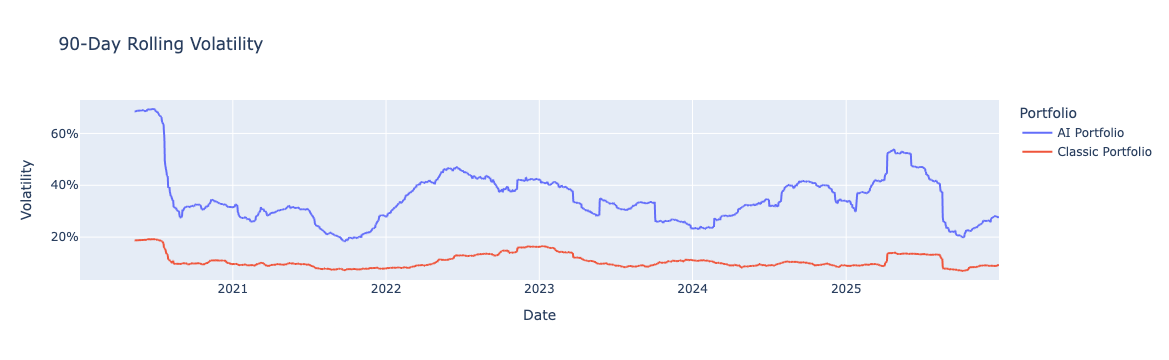

In [31]:
# Volatility chart
fig = px.line(
    volatility,
    x='Date',
    y=['AI Portfolio', 'Classic Portfolio'],
    title='90-Day Rolling Volatility'
)

fig.update_layout(
    yaxis_tickformat='.0%',
    yaxis_title='Volatility',
    xaxis_title='Date',
    legend_title='Portfolio'
)

fig.show()

Volatility Analysis: As expected, the classic portfolio maintained a relatively stable volatility profile, generally ranging between **10%** and **20%**. In contrast, the AI portfolio had significantly higher and more unpredictable fluctuations, with volatility levels averaging around **40%** and peaking near **70%** during the 2020 market crash. This consistently higher volatility, especially during periods of systemic stress, confirms that the AI portfolio's superior returns come at the cost of substantially higher market risk.

### Drawdowns & Recovery

In [32]:
# A new temporary table for Drawdowns chart
dd = pd.DataFrame({
    'Date': growth_ai.index,
    'AI_Portfolio': growth_ai,
    'Classic_Portfolio': growth_classic,
   
})

# The previous high for each portfolio
dd['AI_Peak'] = dd['AI_Portfolio'].cummax()

dd['Classic_Peak'] = dd['Classic_Portfolio'].cummax()
# Calculating drawdowns
dd['AI_Drawdown'] = (
    dd['AI_Portfolio'] / dd['AI_Peak'] - 1
)

dd['Classic_Drawdown'] = (
    dd['Classic_Portfolio'] / dd['Classic_Peak'] - 1
)
dd.head()

,Date,AI_Portfolio,Classic_Portfolio,AI_Peak,Classic_Peak,AI_Drawdown,Classic_Drawdown
Date,,,,,,,
2020-01-03,2020-01-03,9820.357061,10070.320442,9820.357061,10070.320442,0.000000,0.000000
2020-01-06,2020-01-06,9837.649229,10099.275880,9837.649229,10099.275880,0.000000,0.000000
2020-01-07,2020-01-07,9836.161825,10086.509548,9837.649229,10099.275880,-0.000151,-0.001264
2020-01-08,2020-01-08,9853.634737,10056.979678,9853.634737,10099.275880,0.000000,-0.004188
2020-01-09,2020-01-09,9904.359114,10072.534175,9904.359114,10099.275880,0.000000,-0.002648


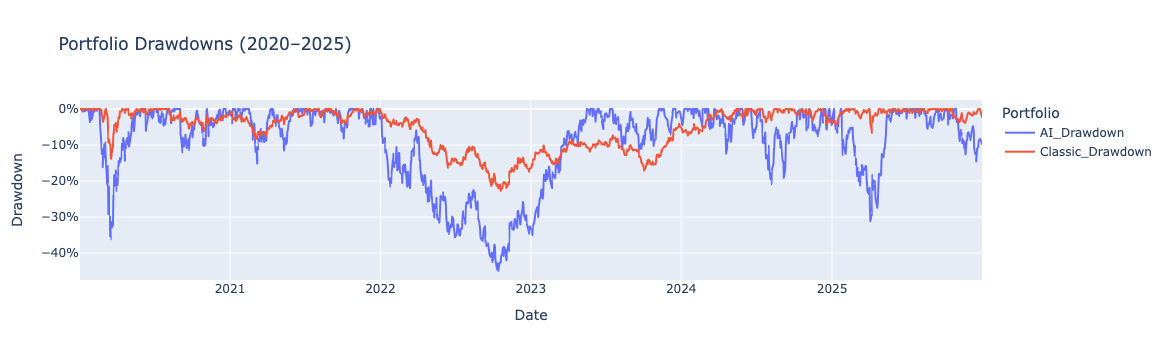

In [33]:
# Drawdowns chart
fig_dd = px.line(
    dd,
    x='Date',
    y=['AI_Drawdown', 'Classic_Drawdown'],
    title='Portfolio Drawdowns (2020–2025)'
)

fig_dd.update_layout(
    xaxis_title='Date',
    yaxis_title='Drawdown',
    legend_title='Portfolio',
    yaxis_tickformat='.0%'
)

fig_dd.show()

In [34]:
# The maximum drawdown
max_dd_ai = dd['AI_Drawdown'].min()
max_dd_classic = dd['Classic_Drawdown'].min()

print(f"AI Maximum Drawdown: {max_dd_ai:.2%}")
print(f"Classic Maximum Drawdown: {max_dd_classic:.2%}")

AI Maximum Drawdown: -45.00%
Classic Maximum Drawdown: -22.74%


The drawdown analysis shows a clear difference in downside risk. The AI portfolio experienced a maximum drawdown of **−45.00%**, almost twice as deep as the Classic portfolio's **−22.74%**.

In [35]:
# Portfolio Reactions to Macroeconomic Factors"
events = {
    "COVID-19 & Oil Shock": ("2020-02-19", "2020-03-25"),
    "Inflation & Rising Rates": ("2022-01-04", "2022-10-25"),
    "U.S. Banking Crisis": ("2023-02-15", "2023-04-15"),
    "Trade & Policy Uncertainty": ("2025-03-01", "2025-05-31")
}

In [36]:
# Figuring out the drawdowns for the specified crises
event_drawdowns = []

for event, (start, end) in events.items():
    
    period = dd.loc[start:end]
    
    ai_min = period["AI_Drawdown"].min()
    classic_min = period["Classic_Drawdown"].min()
    
    event_drawdowns.append({
        "Event": event,
        "AI_Drawdown": ai_min,
        "Classic_Drawdown": classic_min
    })

event_drawdowns = pd.DataFrame(event_drawdowns)

event_drawdowns.round(4)

,Event,AI_Drawdown,Classic_Drawdown
0,COVID-19 & Oil Shock,-0.3619,-0.1383
1,Inflation & Rising Rates,-0.4500,-0.2274
2,U.S. Banking Crisis,-0.2199,-0.1539
3,Trade & Policy Uncertainty,-0.3118,-0.0664


In [37]:
# The date of the maximum drawdown for each portfolio in each event
event_details = []

for event, (start, end) in events.items():
    
    period = dd.loc[start:end]
    
    ai_bottom_date = period["AI_Drawdown"].idxmin()
    classic_bottom_date = period["Classic_Drawdown"].idxmin()
    
    ai_drawdown = period.loc[ai_bottom_date, "AI_Drawdown"]
    classic_drawdown = period.loc[classic_bottom_date, "Classic_Drawdown"]
    
    event_details.append({
        "Event": event,
        "AI_Bottom": ai_bottom_date,
        "AI_Drawdown": ai_drawdown,
        "Classic_Bottom": classic_bottom_date,
        "Classic_Drawdown": classic_drawdown
    })

event_details = pd.DataFrame(event_details)

event_details

,Event,AI_Bottom,AI_Drawdown,Classic_Bottom,Classic_Drawdown
0,COVID-19 & Oil Shock,2020-03-18,-0.361873,2020-03-18,-0.138271
1,Inflation & Rising Rates,2022-10-14,-0.449952,2022-10-20,-0.227369
2,U.S. Banking Crisis,2023-02-22,-0.219909,2023-02-24,-0.153888
3,Trade & Policy Uncertainty,2025-04-04,-0.311769,2025-04-08,-0.066426


In [38]:
# Recovery time
recovery_results = []

for _, row in event_details.iterrows():
    
    event = row["Event"]
    
    # AI
    ai_bottom = row["AI_Bottom"]
    ai_peak_value = dd.loc[ai_bottom, "AI_Peak"]
    
    ai_after_bottom = dd.loc[ai_bottom:]
    ai_recovery_dates = ai_after_bottom[
        ai_after_bottom["AI_Portfolio"] >= ai_peak_value
    ].index

    if len(ai_recovery_dates) > 0:
        ai_recovery = ai_recovery_dates[0]
        ai_recovery_days = len(dd.loc[ai_bottom:ai_recovery]) - 1
    else:
        ai_recovery = None
        ai_recovery_days = None

    # Traditional
    classic_bottom = row["Classic_Bottom"]
    classic_peak_value = dd.loc[classic_bottom, "Classic_Peak"]
    
    classic_after_bottom = dd.loc[classic_bottom:]
    classic_recovery_dates = classic_after_bottom[
        classic_after_bottom["Classic_Portfolio"] >= classic_peak_value
    ].index
    
    if len(classic_recovery_dates) > 0:
        classic_recovery = classic_recovery_dates[0]
        classic_recovery_days = len(
            dd.loc[classic_bottom:classic_recovery]
        ) - 1
    else:
        classic_recovery = None
        classic_recovery_days = None

    recovery_results.append({
        "Event": event,
        "AI_Bottom": ai_bottom,
        "AI_Recovery": ai_recovery,
        "AI_Recovery_Days": ai_recovery_days,
        "Classic_Bottom": classic_bottom,
        "Classic_Recovery": classic_recovery,
        "Classic_Recovery_Days": classic_recovery_days
    })

recovery_results = pd.DataFrame(recovery_results)

recovery_results

,Event,AI_Bottom,AI_Recovery,AI_Recovery_Days,Classic_Bottom,Classic_Recovery,Classic_Recovery_Days
0,COVID-19 & Oil Shock,2020-03-18,2020-05-20,44,2020-03-18,2020-04-14,18
1,Inflation & Rising Rates,2022-10-14,2023-05-17,147,2022-10-20,2024-04-09,367
2,U.S. Banking Crisis,2023-02-22,2023-05-17,59,2023-02-24,2024-04-09,281
3,Trade & Policy Uncertainty,2025-04-04,2025-05-29,37,2025-04-08,2025-04-24,11


**The largest and most painful drawdown occurred in 2022. The combination of high inflation and rising interest rates hit both portfolios hard, reducing the AI portfolio by almost half at its trough and the Classic portfolio by 22%, which is also significant for a more stable portfolio.**

**As expected, the AI portfolio had deeper drawdowns during periods of market stress, especially during the rising rates, which typically puts heavy pressure.**

**The recovery periods were more surprising. Despite much deeper drawdowns, the AI portfolio recovered faster on average than the Classic portfolio, which is a significant advantage. However, the AI recovery coincided with the strong AI boom, which provided an exceptional hype and fundamental growth to technology stocks. The Classic portfolio recovered much more slowly at that period.
This raises an important question: how would the technology portfolio have performed without the exceptional popularity and growth of AI?**

## 4.Risk-Adjusted Performance

### Sharpe
The average 5-year U.S. Treasury yield was used as a proxy for the risk-free rate.

In [39]:
# Risk rate dowloading via yfinance
risk_rate = yf.download(
    "^FVX",
    start="2020-01-01",
    end="2026-01-01",
    progress=False
) ['Close']

In [40]:
# Average rate
avg_risk_rate= risk_rate.mean
avg_risk_rate = float(risk_rate.mean().iloc[0])
print(f"Average 5-Year Treasury Yield: {avg_risk_rate:.2f}%")

Average 5-Year Treasury Yield: 2.75%


In [41]:
# Turning 2.75% into decimal
risk_free_rate = 2.75 / 100
# Converting the annual rate to a daily rate
daily_rf = (1 + risk_free_rate) ** (1 / 252) - 1
# Portfolio return above the risk-free rate
excess_ai = returns['AI_Portfolio'] - daily_rf
excess_classic = returns['Classic_Portfolio'] - daily_rf

In [42]:
# Sharpe Ratio
sharpe_ai = excess_ai.mean() / excess_ai.std() * np.sqrt(252)
sharpe_classic = excess_classic.mean() / excess_classic.std() * np.sqrt(252)
print(f"AI Portfolio Sharpe Ratio: {sharpe_ai:.2f}")
print(f"Classic Portfolio Sharpe Ratio: {sharpe_classic:.2f}")

AI Portfolio Sharpe Ratio: 1.25
Classic Portfolio Sharpe Ratio: 0.68


The AI portfolio had a higher Sharpe Ratio (1.25) than the Classic portfolio (0.68), showing better risk-adjusted performance.

### Sortino

In [43]:
down_ai = np.minimum(excess_ai, 0)
down_classic = np.minimum(excess_classic, 0)
sortino_ai = excess_ai.mean() / down_ai.std() * np.sqrt(252)
sortino_classic = excess_classic.mean() / down_classic.std() * np.sqrt(252)
print(f"AI Portfolio Sortino Ratio: {sortino_ai:.2f}")
print(f"Classic Portfolio Sortino Ratio: {sortino_classic:.2f}")

AI Portfolio Sortino Ratio: 2.11
Classic Portfolio Sortino Ratio: 1.12


**The AI portfolio achieved higher Sharpe and Sortino ratios than the Classic portfolio. Despite its higher volatility and deeper drawdowns, its returns were stronger relative to both total risk and downside risk.**

## 5.Correlation & Diversification
In this part of the analysis, I will use a heat map to compare the portfolios: their assets and daily returns.

In [44]:
# A new temporary table
correlation = returns[
    ['NVDA', 'MSFT', 'AVGO', 'GLD', 'SPY', 'TLT']
]

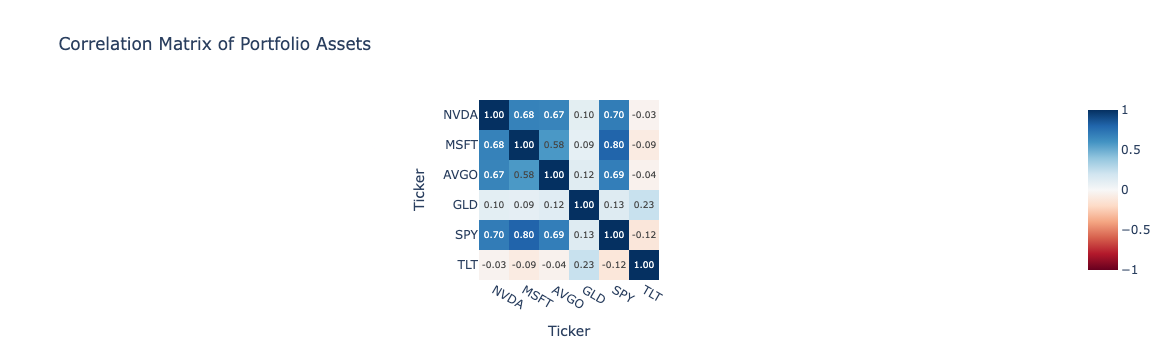

In [45]:
# Calculating
correlation_cal = correlation.corr()

# Chart
fig = px.imshow(
    correlation_cal,
    text_auto=".2f",
    title="Correlation Matrix of Portfolio Assets",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1
)

fig.show()

In [46]:
correlation_cal.round(2)

Ticker,NVDA,MSFT,AVGO,GLD,SPY,TLT
Ticker,,,,,,
NVDA,1.00,0.68,0.67,0.10,0.70,-0.03
MSFT,0.68,1.00,0.58,0.09,0.80,-0.09
AVGO,0.67,0.58,1.00,0.12,0.69,-0.04
GLD,0.10,0.09,0.12,1.00,0.13,0.23
SPY,0.70,0.80,0.69,0.13,1.00,-0.12
TLT,-0.03,-0.09,-0.04,0.23,-0.12,1.00


**As expected, the AI portfolio has weaker diversification than the Classic portfolio. The technology stocks tend to move in the same direction, while the Classic portfolio combines assets with lower correlations, which helps to diversify risk. SPY is moderately correlated with the AI stocks, while gold adds another layer of diversification.**

## 6. Final Performance & Summary

In [47]:
final_summary = pd.DataFrame({
    "AI Portfolio": [
        total_return_ai,
        cagr_ai * 100,
        max_dd_ai * 100,
        sharpe_ai,
        sortino_ai
    ],
    "Classic Portfolio": [
        total_return_classic,
        cagr_classic * 100,
        max_dd_classic * 100,
        sharpe_classic,
        sortino_classic
    ]
}, index=[
    "Total Cumulative Return (%)",
    "CAGR (%)",
    "Maximum Drawdown (%)",
    "Sharpe Ratio",
    "Sortino Ratio"
])

final_summary.round(2)

,AI Portfolio,Classic Portfolio
Total Cumulative Return (%),1142.61,78.94
CAGR (%),52.26,10.20
Maximum Drawdown (%),-45.00,-22.74
Sharpe Ratio,1.25,0.68
Sortino Ratio,2.11,1.12


## Conclusion

**The analysis shows that the AI portfolio significantly outperformed the Classic portfolio over the five-year period, delivering much higher cumulative returns and CAGR, while also achieving higher Sharpe and Sortino ratios. However, this performance came with substantially higher volatility, deeper and more frequent drawdowns, and weaker diversification within the portfolio. The strong performance of the technology sector and the global AI boom coincided with faster recovery from several market shocks, while the Classic portfolio generally recovered more slowly but experienced smaller losses. Therefore, the choice between the two portfolios depends on the investor's strategy and risk tolerance: the AI portfolio represents a more aggressive growth-oriented strategy, while the Classic portfolio provides a more conservative and diversified approach.**